## Activity 1

Identify a data set that you will be using. Provide a link to the data set. 
Describe anything in the data that will need to be cleaned up or modified in some way before you will be able to make graphs from it. 
What additional information could be useful to supplement this data set? Describe at least three variables beyond what is included in the data set that could be valuable to find and merge with this data. 




## Activity 2

Each member of the group should make a graph looking at something from the data set. Include these graphs, and label who created each graph. For the moment, this is completely open-ended. We're not trying to do anything specific yet, just starting to get used to loading this data into R and working with it.

In [ ]:
import chardet
import matplotlib.pyplot as plt
import pandas as pd

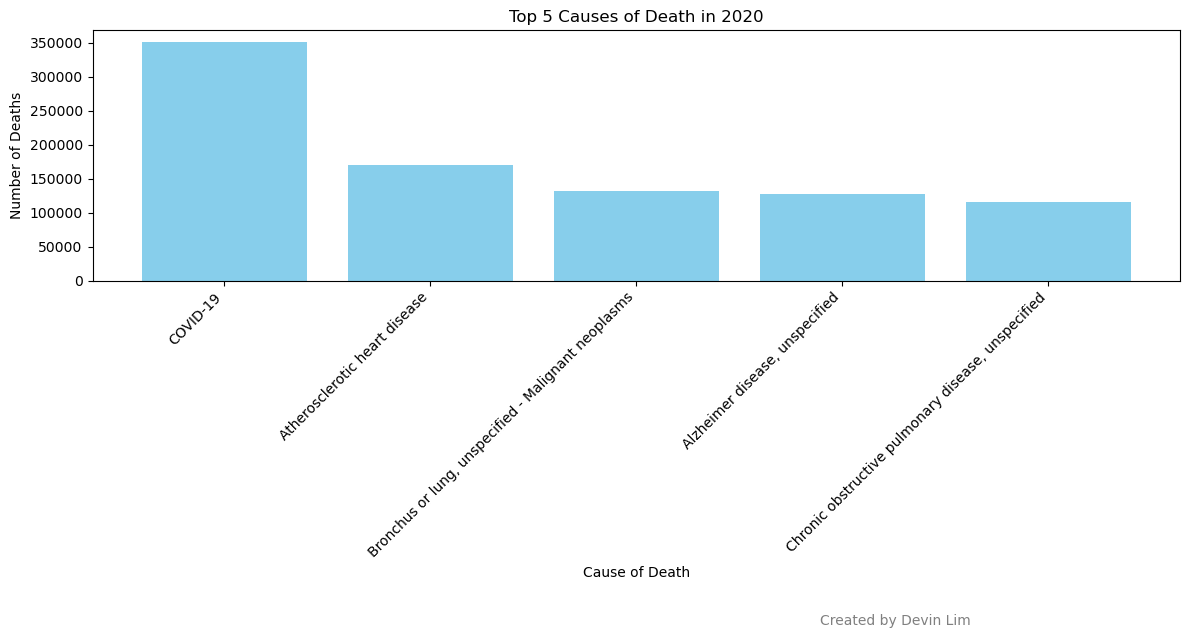

In [3]:
underlying_cause_of_death = "../datasets/raw/Underlying_Cause_of_Death_2022.csv"
underlying_cause_of_death_cols = [
    "Year",
    "Cause of death",
    "Cause of death Code",
    "Deaths",
    "Population",
    "Crude Rate",
]
underlying_cause_of_death_dtype = {
    # capital I or capital F for nullable types
    "Year": "category",
    "Cause of death": "category",
    "Cause of death Code": "category",
    "Deaths": "Int32",
    "Population": "Int32",
    "Crude Rate": "Float32",
}

# somehow it's not UTF-8 encoded
with open(underlying_cause_of_death, "rb") as file:
    raw = file.read()
    encoding = chardet.detect(raw)["encoding"]

df = pd.read_csv(
    underlying_cause_of_death,
    encoding=encoding,
    usecols=underlying_cause_of_death_cols,
    dtype=underlying_cause_of_death_dtype,
    na_values=["Unreliable"],
)

/var/folders/_d/ncq1_ycx743dwrbgqss9z7hr0000gn/T/ipykernel_64159/3418364273.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_heart.groupby("Year")["Crude Rate"].mean().reset_index()


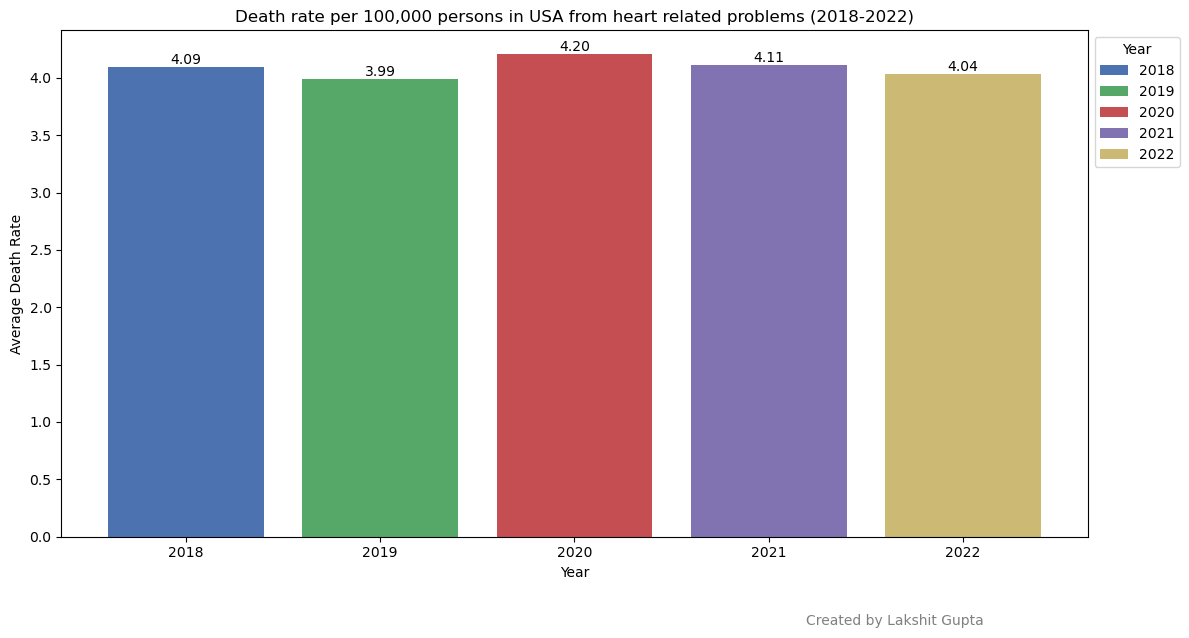

In [4]:
top_5_causes_2020 = (
    df[df["Year"] == "2020"]
    .groupby("Cause of death", observed=True)["Deaths"]
    .sum()
    .reset_index()
    .sort_values("Deaths", ascending=False)
    .head(5)
)

plt.figure(figsize=(12, 6))
plt.bar(
    top_5_causes_2020["Cause of death"], top_5_causes_2020["Deaths"], color="skyblue"
)
plt.title("Top 5 Causes of Death in 2020")
plt.xlabel("Cause of Death")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=45, ha="right")
plt.figtext(0.75, -0.05, "Created by Devin Lim", ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.show()

In [ ]:
data_heart = df[df["Cause of death"].str.contains("heart", case=False, na=False)]
data_heart.loc[:, "Crude Rate"] = pd.to_numeric(
    data_heart["Crude Rate"], errors="coerce"
)

average_crude_rate_per_year = (
    data_heart.groupby("Year")["Crude Rate"].mean().reset_index()
)

plt.figure(figsize=(12, 6))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
bars = plt.bar(
    average_crude_rate_per_year["Year"],
    average_crude_rate_per_year["Crude Rate"],
    color=colors,
)

# Add data labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Custom legend
plt.legend(
    bars,
    [int(year) for year in average_crude_rate_per_year["Year"]],
    title="Year",
    bbox_to_anchor=(1, 1),
    loc="upper left",
)

plt.xlabel("Year")
plt.ylabel("Average Death Rate")
plt.title(
    "Death rate per 100,000 persons in USA from heart related problems (2018-2022)"
)

plt.figtext(
    0.75, -0.05, "Created by Lakshit Gupta", ha="center", fontsize=10, color="gray"
)
plt.tight_layout()
plt.show()